# Geração de Planificações: Tetraflexágono (Hexa-tetraflexágono de 6 Faces)
**Projeto EnIMaR 2026 — Coleção Matemática Fora da Caixa / UFMG**

O **tetraflexágono de 6 faces** é um brinquedo topológico confeccionado a partir de uma malha quadrada $4 \times 4$ com orifício central $2 \times 2$ (um anel de 12 quadrados conectados, resultando em 24 faces elementares distribuídas entre frente e verso).

Através de dobras e flexões ao longo dos eixos horizontais e verticais, o flexágono revela ciclicamente suas 6 faces:
- **Face 1** (Verso)
- **Face 2** (Frente)
- **Face 3** (Verso)
- **Face 4** (Frente)
- **Face 5** (Verso)
- **Face 6** (Frente)

Neste notebook:
1. Carregamos e inspecionamos as 6 imagens de entrada presentes na subpasta `imgs/`.
2. Geramos a planificação **sem marcas de corte** (`grafica=False`) para visualização e prototipagem.
3. Geramos a planificação **com marcas de corte e sangrias** (`grafica=True`) pronta para envio à gráfica profissional.
4. Exibimos a comparação direta entre ambos os formatos.


In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# Configuração de caminhos do projeto
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]
FLEXAGONS_DIR = PROJECT_ROOT / "Flexagons"

for p in [str(PROJECT_ROOT), str(FLEXAGONS_DIR), str(FLEXAGONS_DIR / "Tetraflexagonos")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from Tetraflexagonos.tetraflexagonos import plano

IMG_DIR = NOTEBOOK_DIR / "imgs"
print(f"Diretório de trabalho: {NOTEBOOK_DIR}")
print(f"Subpasta de imagens:  {IMG_DIR}")
face_files = sorted([f for f in IMG_DIR.glob("face*.png") if not f.is_symlink() or True])
print(f"Faces encontradas: {[f.name for f in face_files]}")


Diretório de trabalho: /Users/gabrielribeiro/UFMG/EnIMaR/Flexagons/Examples/Tetraflexagonos
Subpasta de imagens:  /Users/gabrielribeiro/UFMG/EnIMaR/Flexagons/Examples/Tetraflexagonos/imgs
Faces encontradas: ['face1.png', 'face2.png', 'face3.png', 'face4.png', 'face5.png', 'face6.png']


## 1. Visualização das 6 Faces de Entrada (`imgs/`)
Exibição dos 6 arquivos de imagem que compõem as faces do tetraflexágono.

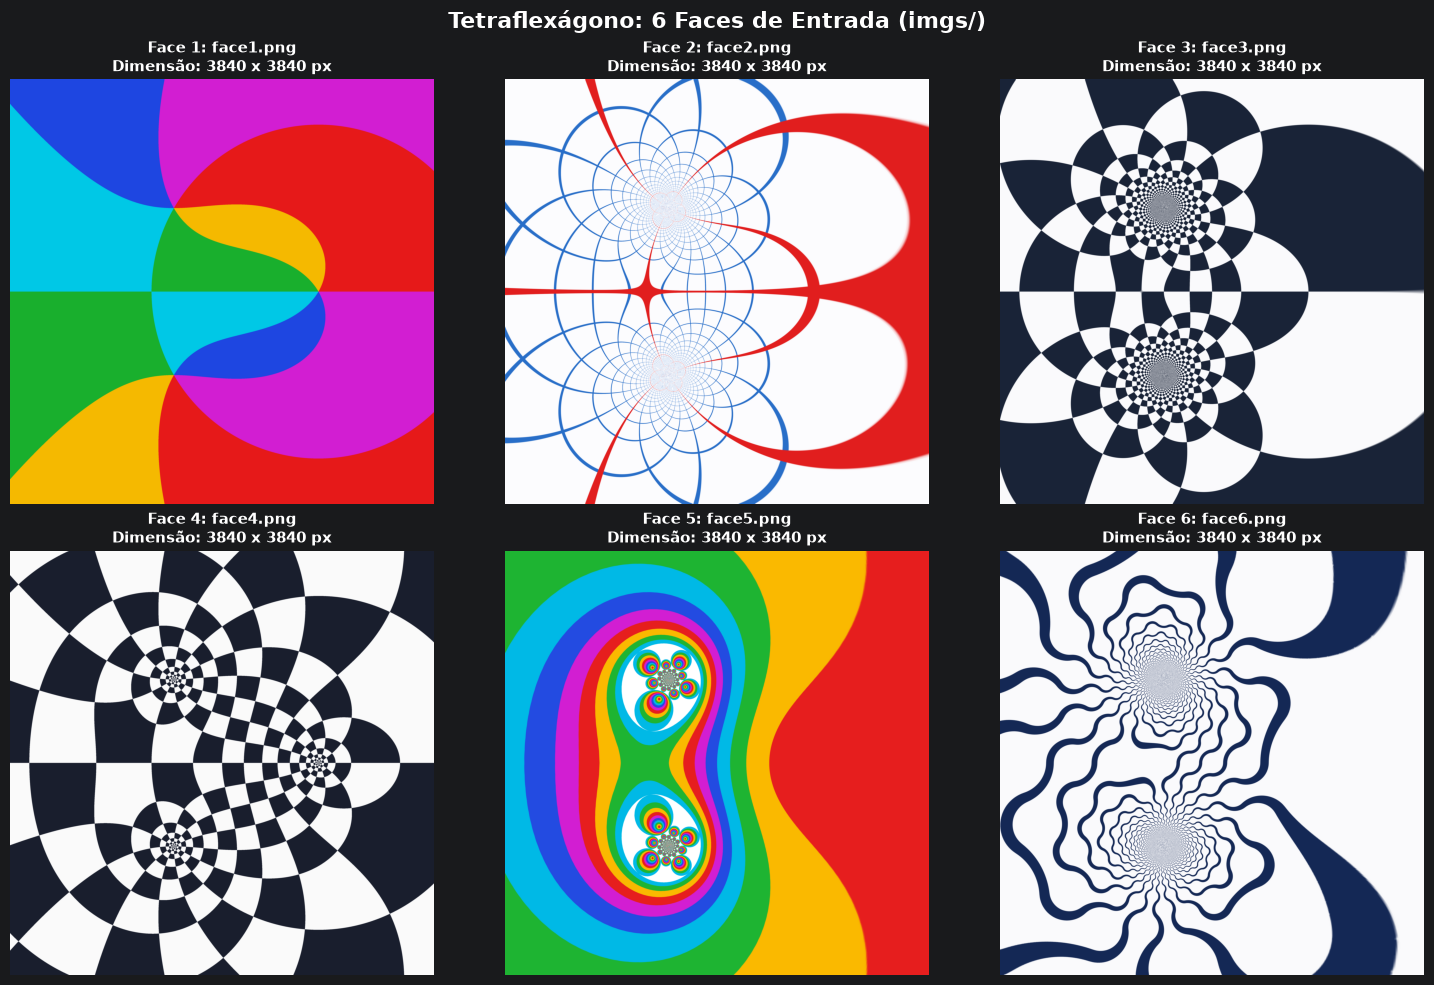

In [2]:
images = [Image.open(f) for f in face_files]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (ax, img, path) in enumerate(zip(axes, images, face_files)):
    ax.imshow(img)
    ax.set_title(f"Face {idx + 1}: {path.name}\nDimensão: {img.width} x {img.height} px", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Tetraflexágono: 6 Faces de Entrada (imgs/)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 2. Geração do Plano Sem Marcas de Corte (`grafica=False`)
Gera a planificação limpa em tamanho base ($2362 \times 2362$ pixels), ideal para montagem manual com tesoura ou prévia digital.

Gerando planos sem marcas de corte...

            >>> CORTANDO IMAGENS <<<
            
REDIMENSIONANDO
CRIANDO PLANOS
-> Plano Frontal (sem marcas):  (2362, 2362) pixels
-> Plano Traseiro (sem marcas): (2362, 2362) pixels


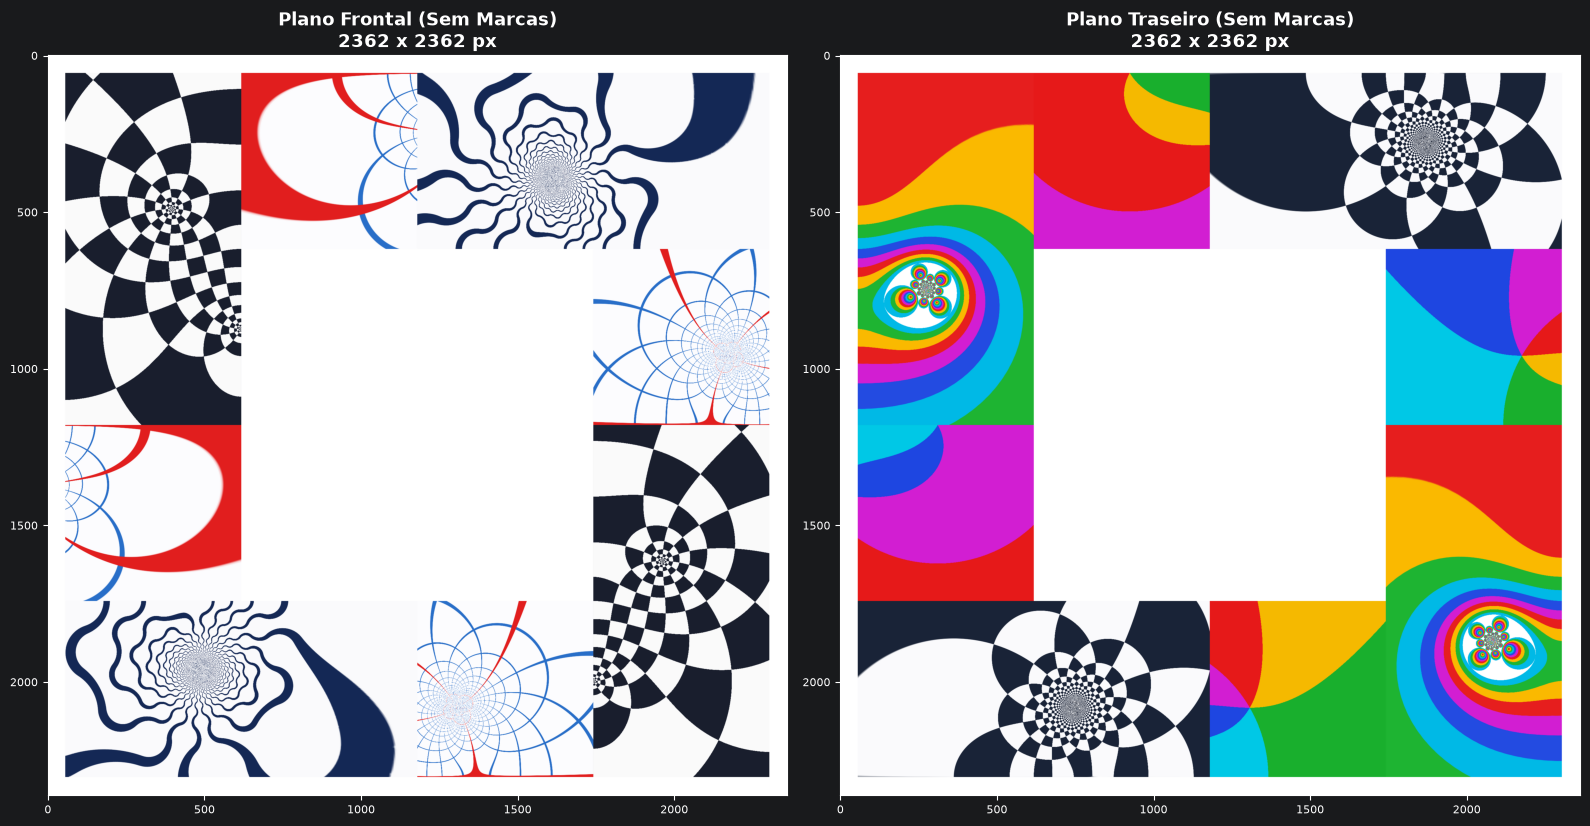

In [3]:
face_paths = [str(f) for f in face_files]

print("Gerando planos sem marcas de corte...")
plano_frontal_sem, plano_traseiro_sem = plano(
    *face_paths,
    grafica=False,
    nome_arq="sem_marcas"
)

print(f"-> Plano Frontal (sem marcas):  {plano_frontal_sem.size} pixels")
print(f"-> Plano Traseiro (sem marcas): {plano_traseiro_sem.size} pixels")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.imshow(plano_frontal_sem)
ax1.set_title(f"Plano Frontal (Sem Marcas)\n{plano_frontal_sem.width} x {plano_frontal_sem.height} px", fontsize=13, fontweight='bold')
ax1.axis('on')
ax1.tick_params(labelsize=8)

ax2.imshow(plano_traseiro_sem)
ax2.set_title(f"Plano Traseiro (Sem Marcas)\n{plano_traseiro_sem.width} x {plano_traseiro_sem.height} px", fontsize=13, fontweight='bold')
ax2.axis('on')
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


## 3. Geração do Plano Com Marcas de Corte para Gráfica (`grafica=True`)
Gera a prancha gráfica profissional ($2420 \times 2420$ pixels) incluindo sangrias externas de 58 px, compensação triangular nas juntas e marcas vetoriais de corte/registro.

Gerando planos com marcas de corte e sangrias para gráfica...

            >>> CORTANDO IMAGENS <<<
            
REDIMENSIONANDO
CRIANDO PLANOS
-> Plano Frontal (com marcas):  (2420, 2420) pixels
-> Plano Traseiro (com marcas): (2420, 2420) pixels


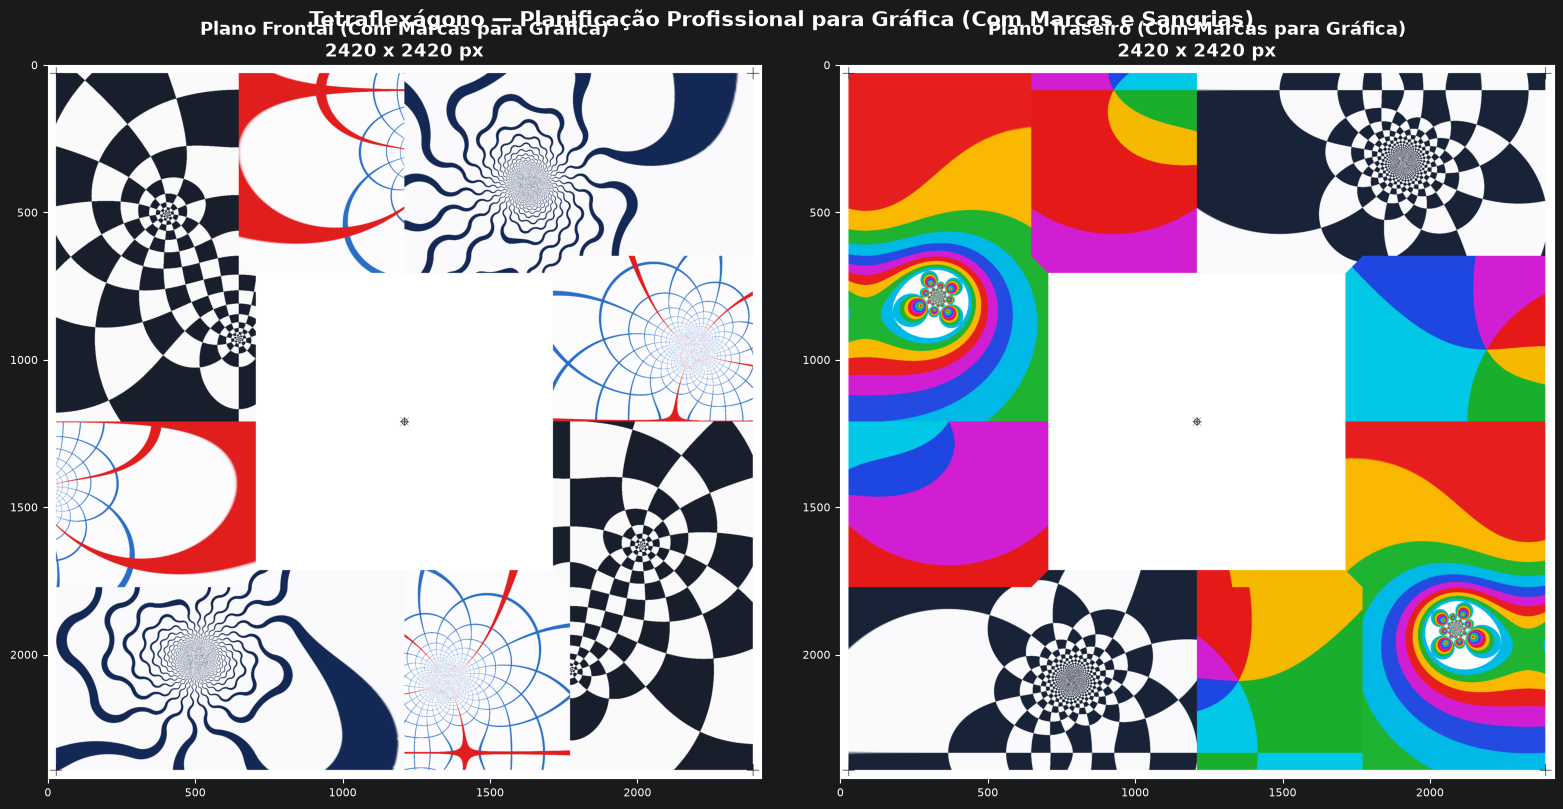

In [4]:
print("Gerando planos com marcas de corte e sangrias para gráfica...")
plano_frontal_com, plano_traseiro_com = plano(
    *face_paths,
    grafica=True,
    nome_arq="com_marcas"
)

print(f"-> Plano Frontal (com marcas):  {plano_frontal_com.size} pixels")
print(f"-> Plano Traseiro (com marcas): {plano_traseiro_com.size} pixels")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.imshow(plano_frontal_com)
ax1.set_title(f"Plano Frontal (Com Marcas para Gráfica)\n{plano_frontal_com.width} x {plano_frontal_com.height} px", fontsize=13, fontweight='bold')
ax1.axis('on')
ax1.tick_params(labelsize=8)

ax2.imshow(plano_traseiro_com)
ax2.set_title(f"Plano Traseiro (Com Marcas para Gráfica)\n{plano_traseiro_com.width} x {plano_traseiro_com.height} px", fontsize=13, fontweight='bold')
ax2.axis('on')
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


## 4. Comparação Lado a Lado (Sem Marcas vs Com Marcas)
Visão comparativa simultânea dos quatro planos gerados.

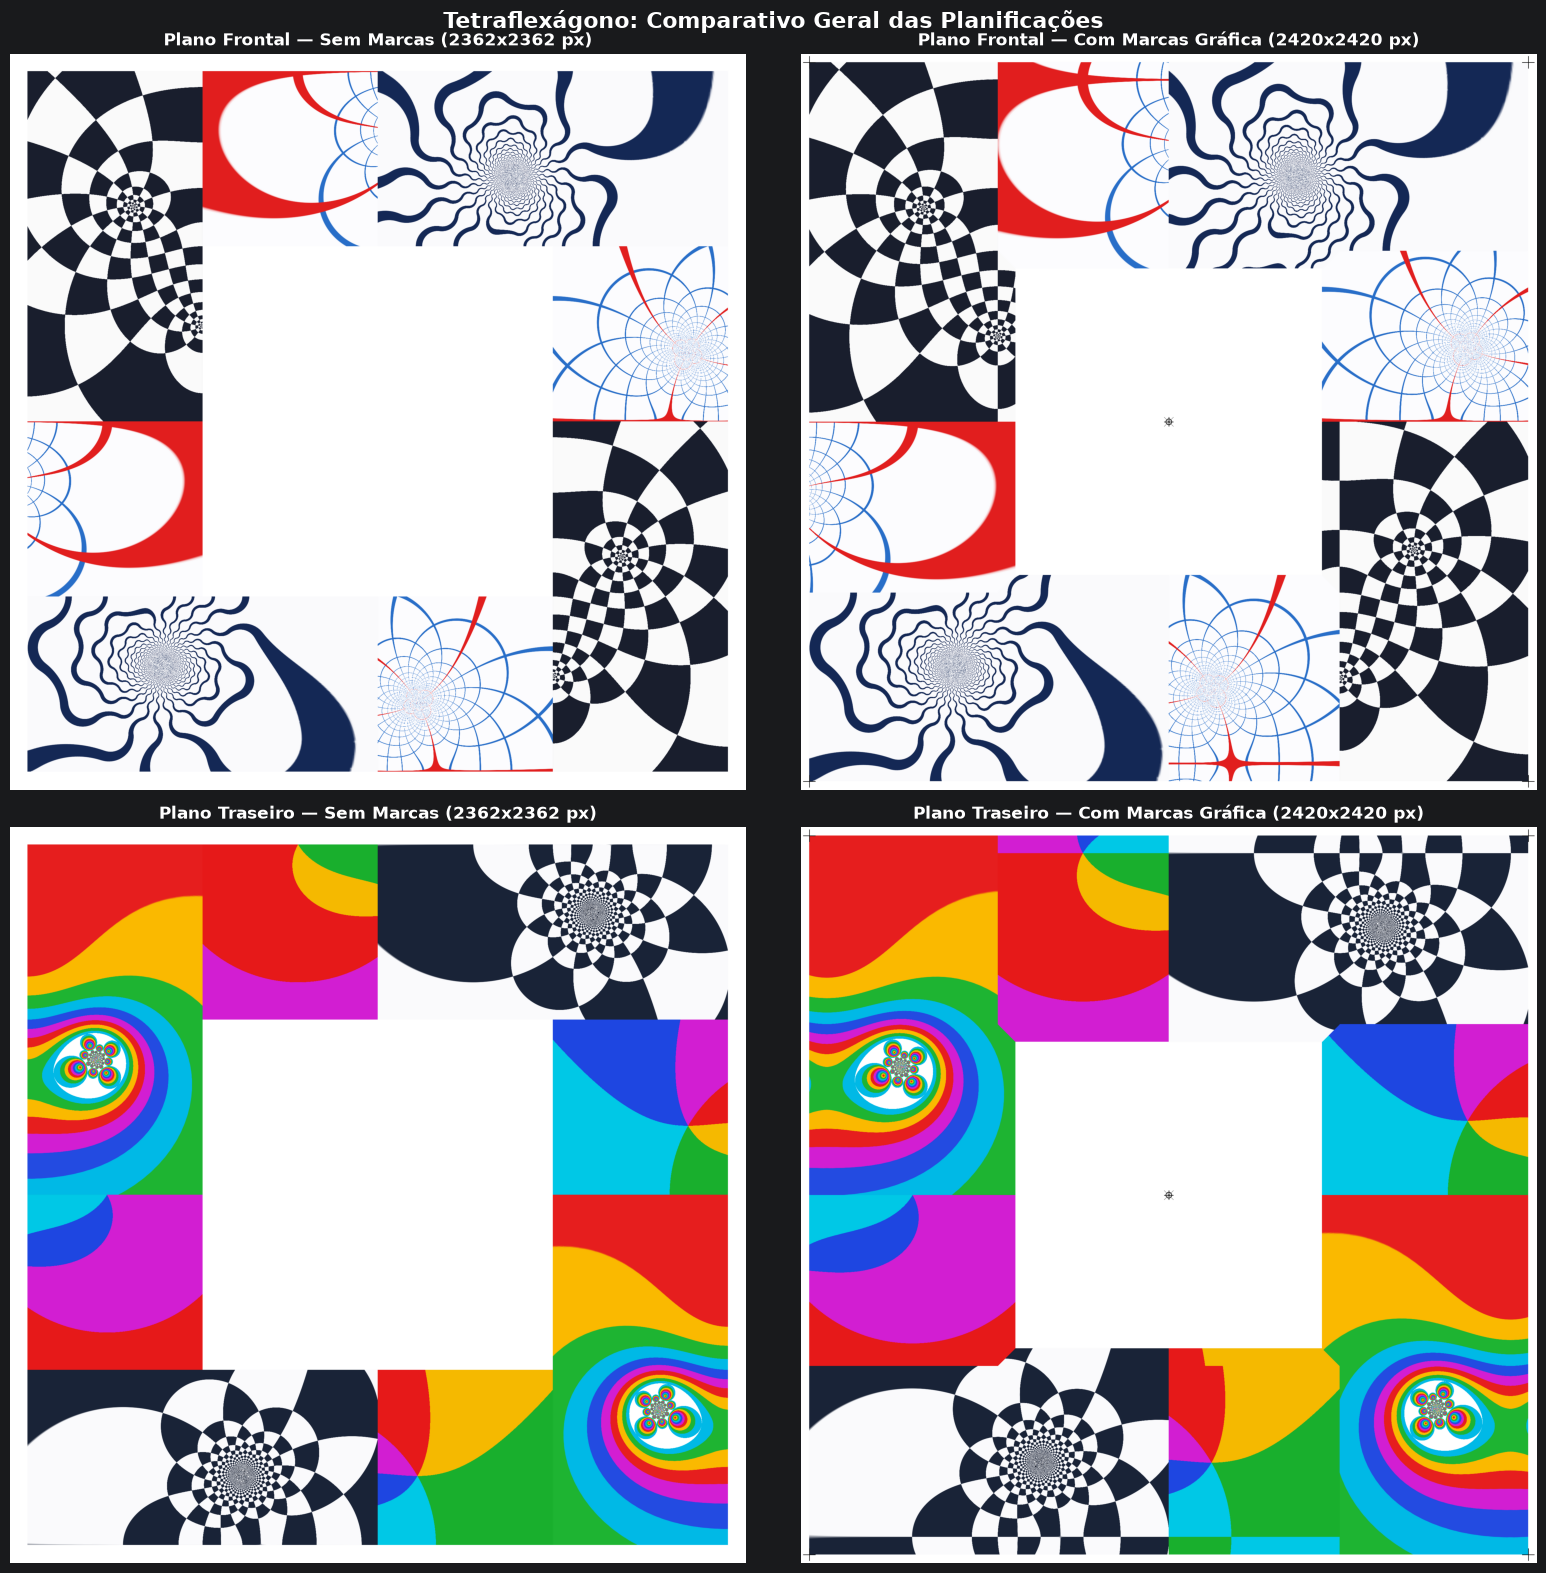

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

axes[0, 0].imshow(plano_frontal_sem)
axes[0, 0].set_title(f"Plano Frontal — Sem Marcas ({plano_frontal_sem.width}x{plano_frontal_sem.height} px)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(plano_frontal_com)
axes[0, 1].set_title(f"Plano Frontal — Com Marcas Gráfica ({plano_frontal_com.width}x{plano_frontal_com.height} px)", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(plano_traseiro_sem)
axes[1, 0].set_title(f"Plano Traseiro — Sem Marcas ({plano_traseiro_sem.width}x{plano_traseiro_sem.height} px)", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(plano_traseiro_com)
axes[1, 1].set_title(f"Plano Traseiro — Com Marcas Gráfica ({plano_traseiro_com.width}x{plano_traseiro_com.height} px)", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("Tetraflexágono: Comparativo Geral das Planificações", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
arquivos = [
    "Plano_Frontal_sem_marcas.png",
    "Plano_Traseiro_sem_marcas.png",
    "Plano_Frontal_com_marcas.png",
    "Plano_Traseiro_com_marcas.png"
]

print("Resumo dos arquivos gerados no diretório do notebook:")
print("-" * 75)
print(f"{'Nome do Arquivo':<34} | {'Dimensões':<14} | {'Tamanho':<10}")
print("-" * 75)
for nome in arquivos:
    p = Path(nome)
    if p.exists():
        size_mb = p.stat().st_size / (1024 * 1024)
        with Image.open(p) as im:
            dim = f"{im.width}x{im.height} px"
        print(f"{nome:<34} | {dim:<14} | {size_mb:6.2f} MB")
    else:
        print(f"{nome:<34} | {'N/A':<14} | {'N/A':<10}")
print("-" * 75)


Resumo dos arquivos gerados no diretório do notebook:
---------------------------------------------------------------------------
Nome do Arquivo                    | Dimensões      | Tamanho   
---------------------------------------------------------------------------
Plano_Frontal_sem_marcas.png       | 2362x2362 px   |   0.92 MB
Plano_Traseiro_sem_marcas.png      | 2362x2362 px   |   0.47 MB
Plano_Frontal_com_marcas.png       | 2420x2420 px   |   1.18 MB
Plano_Traseiro_com_marcas.png      | 2420x2420 px   |   0.60 MB
---------------------------------------------------------------------------
